In [5]:
import os
import sys
os.getcwd()

'/Users/mriganavdas/Documents/credit-default-prediction-cibc/notebooks'

In [8]:
# Add project root to path
sys.path.append(os.path.abspath(".."))
print(os.listdir("../data"))
    

['training.csv', 'test.csv']


In [9]:
import pandas as pd

train = pd.read_csv("../data/training.csv")
test = pd.read_csv("../data/test.csv")


In [11]:

#train.head()


In [13]:
#test.head()

In [14]:
print(train.shape)#(150000,12)



(150000, 12)


In [16]:
print(test.shape) #(101503,12)

(101503, 12)


In [17]:
train['SeriousDlqin2yrs'].value_counts()
'''
0    139974
1     10026
Name: SeriousDlqin2yrs, dtype: int64
'''

0    139974
1     10026
Name: SeriousDlqin2yrs, dtype: int64

In [ ]:
#IMPORTS#

In [18]:
from pathlib import Path
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

warnings.filterwarnings("ignore")

In [22]:
RANDOM_STATE = 42
TARGET_COL = "SeriousDlqin2yrs"

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

In [23]:
print("Base directory:", BASE_DIR)

Base directory: /Users/mriganavdas/Documents/credit-default-prediction-cibc


In [24]:
print("Data directory:", DATA_DIR)

Data directory: /Users/mriganavdas/Documents/credit-default-prediction-cibc/data


In [25]:
print("Output directory:", OUTPUT_DIR)

Output directory: /Users/mriganavdas/Documents/credit-default-prediction-cibc/outputs


In [26]:
train_df = pd.read_csv(DATA_DIR / "training.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

In [27]:
train_df = train_df.drop(columns=["Unnamed: 0"], errors="ignore")
test_df = test_df.drop(columns=["Unnamed: 0"], errors="ignore")

In [28]:
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

Training shape: (150000, 11)
Test shape: (101503, 11)


In [29]:
print("Training columns:")
print(train_df.columns.tolist())

Training columns:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [30]:
print("\nMissing values in training:")
print(train_df.isnull().sum().sort_values(ascending=False))


Missing values in training:
MonthlyIncome                           29731
NumberOfDependents                       3924
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
dtype: int64


In [31]:
print("\nMissing values in test:")
print(test_df.isnull().sum().sort_values(ascending=False))


Missing values in test:
SeriousDlqin2yrs                        101503
MonthlyIncome                            20103
NumberOfDependents                        2626
RevolvingUtilizationOfUnsecuredLines         0
age                                          0
NumberOfTime30-59DaysPastDueNotWorse         0
DebtRatio                                    0
NumberOfOpenCreditLinesAndLoans              0
NumberOfTimes90DaysLate                      0
NumberRealEstateLoansOrLines                 0
NumberOfTime60-89DaysPastDueNotWorse         0
dtype: int64


In [32]:
print("\nTarget distribution:")
print(train_df[TARGET_COL].value_counts(dropna=False))
print(train_df[TARGET_COL].value_counts(normalize=True).rename("proportion"))


Target distribution:
0    139974
1     10026
Name: SeriousDlqin2yrs, dtype: int64
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [33]:
TARGET_COL = "SeriousDlqin2yrs"

X = train_df.drop(columns=[TARGET_COL], errors="ignore").copy()
y = train_df[TARGET_COL].copy()
X_test = test_df.copy()

common_cols = [c for c in X.columns if c in X_test.columns]
X = X[common_cols].copy()
X_test = X_test[common_cols].copy()

In [34]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)
print("\nFeature columns:")
print(X.columns.tolist())

X shape: (150000, 10)
y shape: (150000,)
X_test shape: (101503, 10)

Feature columns:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [35]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Categorical columns:
[]


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['RevolvingUtilizationOfUnsecuredLines', 'age',
                                  'NumberOfTime30-59DaysPastDueNotWorse',
                                  'DebtRatio', 'MonthlyIncome',
                                  'NumberOfOpenCreditLinesAndLoans',
                                  'NumberOfTimes90DaysLate',
                                  'NumberRealEstateLoansOrLines',
                                  'NumberOfTime60-89DaysPastDueNotWorse',
                                  'NumberOfDependents']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_freque

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (120000, 10)
X_valid: (30000, 10)
y_train: (120000,)
y_valid: (30000,)


In [ ]:
#pip install xgboost

In [39]:
from xgboost import XGBClassifier

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "logistic_regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

try:
    from xgboost import XGBClassifier
    models["xgboost"] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    print("XGBoost added")
except:
    print("XGBoost not installed")

models

XGBoost added


{'logistic_regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
 'random_forest': RandomForestClassifier(class_weight='balanced_subsample', max_depth=8,
                        min_samples_leaf=20, n_estimators=300, n_jobs=-1,
                        random_state=42),
 'gradient_boosting': GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                            random_state=42),
 'xgboost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.05, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
      

In [41]:
def compute_ks(y_true, y_score):
    import pandas as pd
    import numpy as np
    
    df = pd.DataFrame({"y": y_true, "score": y_score}).sort_values("score", ascending=False)
    bad = (df["y"] == 1).astype(int)
    good = (df["y"] == 0).astype(int)
    
    cum_bad = bad.cumsum() / bad.sum()
    cum_good = good.cumsum() / good.sum()
    
    ks = np.max(np.abs(cum_bad - cum_good))
    return ks

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
pipelines = {}

for name, model in models.items():
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Cross-validation
    cv_auc = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )
    
    # Fit model
    pipeline.fit(X_train, y_train)
    
    # Validation predictions
    prob = pipeline.predict_proba(X_valid)[:, 1]
    
    results.append({
        "model": name,
        "cv_auc": cv_auc.mean(),
        "val_auc": roc_auc_score(y_valid, prob),
        "pr_auc": average_precision_score(y_valid, prob),
        "ks": compute_ks(y_valid, prob)
    })
    
    pipelines[name] = pipeline
    
    print(f"{name} → AUC: {roc_auc_score(y_valid, prob):.4f}, KS: {compute_ks(y_valid, prob):.4f}")

logistic_regression → AUC: 0.8021, KS: 0.4571
random_forest → AUC: 0.8662, KS: 0.5795
gradient_boosting → AUC: 0.8676, KS: 0.5813
xgboost → AUC: 0.8691, KS: 0.5813


In [44]:
results_df = pd.DataFrame(results).sort_values(by="val_auc", ascending=False)
results_df


,model,cv_auc,val_auc,pr_auc,ks
3,xgboost,0.865409,0.869111,0.408374,0.581318
2,gradient_boosting,0.863308,0.867571,0.410337,0.581254
1,random_forest,0.861349,0.866165,0.396546,0.579520
0,logistic_regression,0.789489,0.802137,0.323428,0.457082


In [45]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = pipelines[best_model_name]

print("Best model:", best_model_name)

Best model: xgboost


In [46]:
best_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['RevolvingUtilizationOfUnsecuredLines',
                                                   'age',
                                                   'NumberOfTime30-59DaysPastDueNotWorse',
                                                   'DebtRatio', 'MonthlyIncome',
                                                   'NumberOfOpenCreditLinesAndLoans',
                                                   'NumberOfTimes90DaysLate',
                                                   'NumberRealEsta...
          

In [47]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

prob = best_pipeline.predict_proba(X_valid)[:, 1]
pred = (prob >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_valid, prob))
print("Precision:", precision_score(y_valid, pred))
print("Recall:", recall_score(y_valid, pred))
print("KS:", compute_ks(y_valid, prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, pred))

AUC: 0.8691111745551285
Precision: 0.6036308623298033
Recall: 0.19900249376558604
KS: 0.5813177362006665

Confusion Matrix:
[[27733   262]
 [ 1606   399]]


In [48]:
results_df = pd.DataFrame(results).sort_values(by="val_auc", ascending=False)
results_df

,model,cv_auc,val_auc,pr_auc,ks
3,xgboost,0.865409,0.869111,0.408374,0.581318
2,gradient_boosting,0.863308,0.867571,0.410337,0.581254
1,random_forest,0.861349,0.866165,0.396546,0.579520
0,logistic_regression,0.789489,0.802137,0.323428,0.457082


In [49]:
test_prob = best_pipeline.predict_proba(X_test)[:, 1]



output = pd.DataFrame({
    "ID": test_df.index,
    "Probability_of_Default": test_prob
})


output.head()

,ID,Probability_of_Default
0,0,0.066319
1,1,0.058379
2,2,0.011356
3,3,0.084616
4,4,0.102049


In [50]:
output_path = OUTPUT_DIR / "test_probabilities.csv"

output.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mriganavdas/Documents/credit-default-prediction-cibc/outputs/test_probabilities.csv


In [51]:
model = best_pipeline.named_steps["model"]

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    print("Top feature importances:")
    print(importances[:10])

Top feature importances:
[0.20160468 0.02302531 0.13820271 0.01725156 0.01615035 0.01922402
 0.40409338 0.03017808 0.13795152 0.01231834]


In [52]:
import pandas as pd

model = best_pipeline.named_steps['model']

feature_names = X.columns

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
6,NumberOfTimes90DaysLate,0.404093
0,RevolvingUtilizationOfUnsecuredLines,0.201605
2,NumberOfTime30-59DaysPastDueNotWorse,0.138203
8,NumberOfTime60-89DaysPastDueNotWorse,0.137952
7,NumberRealEstateLoansOrLines,0.030178
1,age,0.023025
5,NumberOfOpenCreditLinesAndLoans,0.019224
3,DebtRatio,0.017252
4,MonthlyIncome,0.016150
9,NumberOfDependents,0.012318


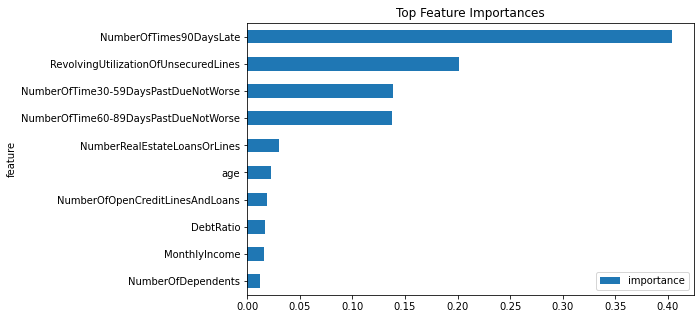

In [53]:
import matplotlib.pyplot as plt

feat_imp.head(10).plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8,5)
)
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.show()

In [ ]:
#pip install shap

In [54]:
import shap
print(shap.__version__)

0.49.1


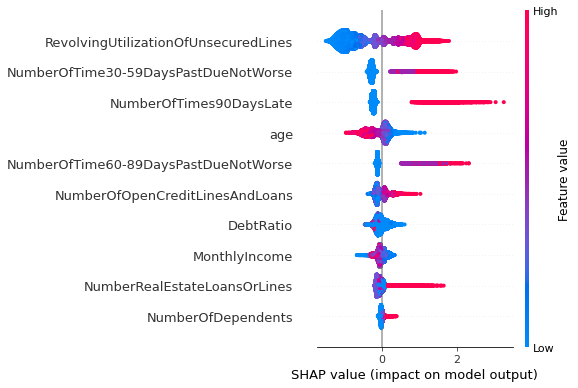

In [55]:
import shap

explainer = shap.Explainer(best_pipeline.named_steps["model"])
shap_values = explainer(best_pipeline.named_steps["preprocessor"].transform(X_valid))

shap.summary_plot(shap_values, X_valid)

In [62]:
preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
model_fitted = best_pipeline.named_steps["model"]

print(type(preprocessor_fitted))
print(type(model_fitted))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'xgboost.sklearn.XGBClassifier'>


In [63]:
X_background = X_train.sample(min(200, len(X_train)), random_state=42)
X_explain = X_valid.head(100).copy()

X_background_t = preprocessor_fitted.transform(X_background)
X_explain_t = preprocessor_fitted.transform(X_explain)

print("Background shape:", X_background_t.shape)
print("Explain shape:", X_explain_t.shape)

Background shape: (200, 10)
Explain shape: (100, 10)


In [64]:
feature_names = X_train.columns.tolist()

print(feature_names)
print("Total features:", len(feature_names))

['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Total features: 10


In [65]:
explainer = shap.Explainer(
    model_fitted,
    X_background_t,
    feature_names=feature_names
)

shap_values = explainer(X_explain_t)

In [66]:
print(len(feature_names))
print(X_explain_t.shape)

10
(100, 10)


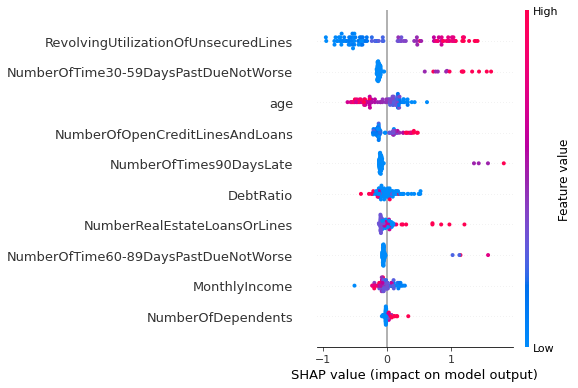

In [67]:
shap.summary_plot(shap_values, X_explain_t, feature_names=feature_names)

In [56]:
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8],
    "model__colsample_bytree": [0.7, 0.8]
}

In [57]:
from sklearn.pipeline import Pipeline

xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

In [58]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring="roc_auc",
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['RevolvingUtilizationOfUnsecuredLines',
                                                                          'age',
                                                                          'NumberOfTime30-59DaysPastDueNotWorse',
                                                                          'DebtRatio',
            

In [59]:
print("Best parameters:")
print(grid.best_params_)

print("\nBest CV AUC:")
print(grid.best_score_)

Best parameters:
{'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best CV AUC:
0.8643346362846841


In [60]:
best_xgb_pipeline = grid.best_estimator_

In [61]:
prob = best_xgb_pipeline.predict_proba(X_valid)[:, 1]

print("AUC:", roc_auc_score(y_valid, prob))
print("KS:", compute_ks(y_valid, prob))

AUC: 0.8690399737395216
KS: 0.5802886069341737
